# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Putri Prayesti
- Email: aeiprsty@gmail.com
- Id Dicoding: pppiiiy

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

### Menyiapkan data yang akan digunakan

In [6]:
df = pd.read_csv("data.csv", sep=";")

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [7]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 4424
Jumlah kolom: 37


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


In [12]:
df.columns.tolist()

['Marital_status',
 'Application_mode',
 'Application_order',
 'Course',
 'Daytime_evening_attendance',
 'Previous_qualification',
 'Previous_qualification_grade',
 'Nacionality',
 'Mothers_qualification',
 'Fathers_qualification',
 'Mothers_occupation',
 'Fathers_occupation',
 'Admission_grade',
 'Displaced',
 'Educational_special_needs',
 'Debtor',
 'Tuition_fees_up_to_date',
 'Gender',
 'Scholarship_holder',
 'Age_at_enrollment',
 'International',
 'Curricular_units_1st_sem_credited',
 'Curricular_units_1st_sem_enrolled',
 'Curricular_units_1st_sem_evaluations',
 'Curricular_units_1st_sem_approved',
 'Curricular_units_1st_sem_grade',
 'Curricular_units_1st_sem_without_evaluations',
 'Curricular_units_2nd_sem_credited',
 'Curricular_units_2nd_sem_enrolled',
 'Curricular_units_2nd_sem_evaluations',
 'Curricular_units_2nd_sem_approved',
 'Curricular_units_2nd_sem_grade',
 'Curricular_units_2nd_sem_without_evaluations',
 'Unemployment_rate',
 'Inflation_rate',
 'GDP',
 'Status']

In [13]:
status_counts = df["Status"].value_counts()

print(status_counts)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


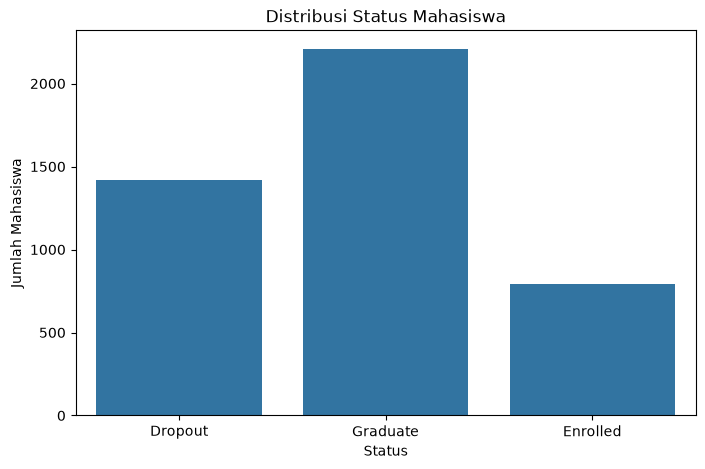

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Status")

plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

In [15]:
status_percentage = df["Status"].value_counts(normalize=True) * 100

print(status_percentage.round(2))

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [16]:
academic_features = [
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
]

df[academic_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Curricular_units_1st_sem_enrolled,4424.0,6.270570,2.480178,0.0,5.00,6.000000,7.000000,26.000000
Curricular_units_1st_sem_evaluations,4424.0,8.299051,4.179106,0.0,6.00,8.000000,10.000000,45.000000
Curricular_units_1st_sem_approved,4424.0,4.706600,3.094238,0.0,3.00,5.000000,6.000000,26.000000
Curricular_units_1st_sem_grade,4424.0,10.640822,4.843663,0.0,11.00,12.285714,13.400000,18.875000
Curricular_units_2nd_sem_enrolled,4424.0,6.232143,2.195951,0.0,5.00,6.000000,7.000000,23.000000
Curricular_units_2nd_sem_evaluations,4424.0,8.063291,3.947951,0.0,6.00,8.000000,10.000000,33.000000
Curricular_units_2nd_sem_approved,4424.0,4.435805,3.014764,0.0,2.00,5.000000,6.000000,20.000000
Curricular_units_2nd_sem_grade,4424.0,10.230206,5.210808,0.0,10.75,12.200000,13.333333,18.571429


In [17]:
df.groupby("Status")[academic_features].mean().round(2)

,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
Status,,,,,,,,
Dropout,5.82,7.75,2.55,7.26,5.78,7.17,1.94,5.90
Enrolled,5.96,9.34,4.32,11.13,5.94,9.44,4.06,11.12
Graduate,6.67,8.28,6.23,12.64,6.63,8.14,6.18,12.70


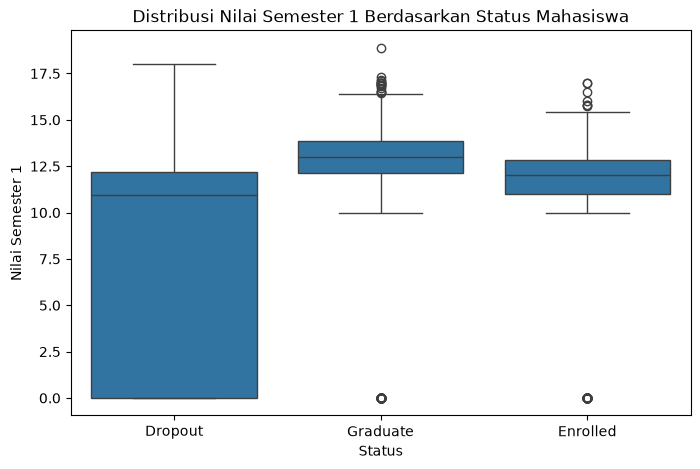

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_grade"
)

plt.title("Distribusi Nilai Semester 1 Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 1")
plt.show()

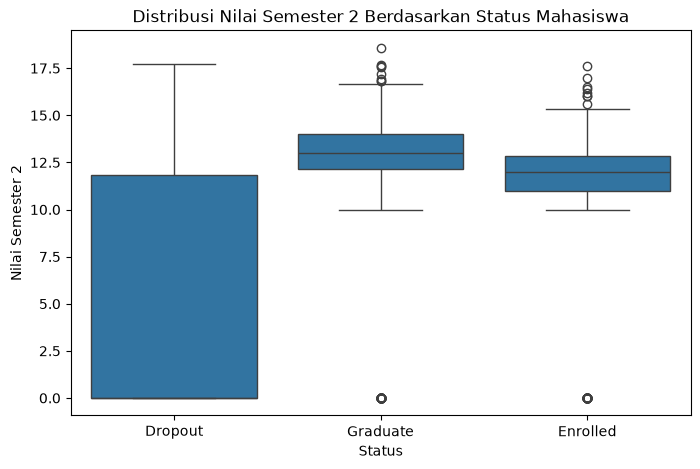

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_grade"
)

plt.title("Distribusi Nilai Semester 2 Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 2")
plt.show()

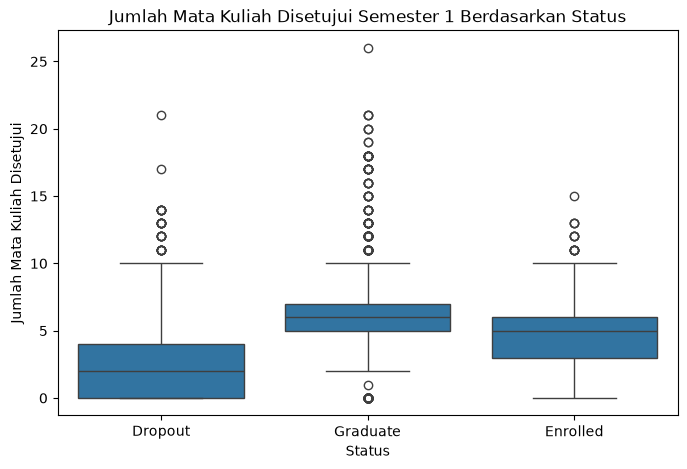

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_approved"
)

plt.title("Jumlah Mata Kuliah Disetujui Semester 1 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

## Data Preparation / Preprocessing

## Modeling

## Evaluation